In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
monthly_df = pd.read_csv(
    "data/processed/monthly_passenger_demand.csv"
)

monthly_df["Month"] = pd.to_datetime(monthly_df["Month"])

monthly_df = (
    monthly_df
    .sort_values("Month")
    .reset_index(drop=True)
)

In [3]:
monthly_df["Lag_1"] = (
    monthly_df["Passenger Count"].shift(1)
)

monthly_df["Lag_2"] = (
    monthly_df["Passenger Count"].shift(2)
)

monthly_df["Lag_12"] = (
    monthly_df["Passenger Count"].shift(12)
)

monthly_df["Rolling_Mean_3"] = (
    monthly_df["Passenger Count"]
    .shift(1)
    .rolling(3)
    .mean()
)

monthly_df["Rolling_Mean_12"] = (
    monthly_df["Passenger Count"]
    .shift(1)
    .rolling(12)
    .mean()
)

monthly_df["Month_Number"] = (
    monthly_df["Month"].dt.month
)

monthly_df = (
    monthly_df
    .dropna()
    .reset_index(drop=True)
)

In [4]:
features = [
    "Lag_1",
    "Lag_2",
    "Lag_12",
    "Rolling_Mean_3",
    "Rolling_Mean_12",
    "Month_Number"
]

X = monthly_df[features]
y = monthly_df["Passenger Count"]

split_index = int(len(monthly_df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

In [5]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [6]:
basic_df = pd.read_csv(
    "data/processed/monthly_passenger_demand.csv"
)

basic_df["Month"] = pd.to_datetime(basic_df["Month"])

basic_df = (
    basic_df
    .sort_values("Month")
    .reset_index(drop=True)
)

basic_df["Previous Month Passengers"] = (
    basic_df["Passenger Count"].shift(1)
)

basic_df = (
    basic_df
    .dropna()
    .reset_index(drop=True)
)

X_basic = basic_df[["Previous Month Passengers"]]
y_basic = basic_df["Passenger Count"]

split_basic = int(len(basic_df) * 0.8)

X_basic_train = X_basic.iloc[:split_basic]
X_basic_test = X_basic.iloc[split_basic:]

y_basic_train = y_basic.iloc[:split_basic]
y_basic_test = y_basic.iloc[split_basic:]

In [7]:
basic_model = LinearRegression()

basic_model.fit(
    X_basic_train,
    y_basic_train
)

basic_pred = basic_model.predict(X_basic_test)

In [8]:
linear_model = LinearRegression()

linear_model.fit(
    X_train,
    y_train
)

linear_pred = linear_model.predict(X_test)

In [9]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)

rf_pred = rf_model.predict(X_test)

In [10]:
evaluation = pd.DataFrame({
    "Month": monthly_df["Month"].iloc[split_index:].values,
    "Actual": y_test.values,
    "Linear Regression": linear_pred,
    "Random Forest": rf_pred
})

In [11]:
evaluation["Linear Error"] = (
    evaluation["Actual"]
    - evaluation["Linear Regression"]
)

evaluation["Random Forest Error"] = (
    evaluation["Actual"]
    - evaluation["Random Forest"]
)

In [12]:
evaluation.head(10)

,Month,Actual,Linear Regression,Random Forest,Linear Error,Random Forest Error
0,2021-04-01,1455944,1.081096e+06,1066235.270,374847.529232,389708.730
1,2021-05-01,1739021,1.429457e+06,1032088.915,309564.404755,706932.085
2,2021-06-01,2245539,1.671740e+06,1148419.655,573798.938896,1097119.345
3,2021-07-01,2732010,2.144374e+06,2003277.440,587635.562366,728732.560
4,2021-08-01,2649154,2.614175e+06,2483266.160,34978.617554,165887.840
5,2021-09-01,2419859,2.496369e+06,2497142.200,-76509.883683,-77283.200
6,2021-10-01,2711638,2.193141e+06,2374828.775,518497.490713,336809.225
7,2021-11-01,2799681,2.462532e+06,2465920.395,337148.891678,333760.605
8,2021-12-01,2915455,2.615309e+06,2461910.770,300145.955713,453544.230
9,2022-01-01,2092568,2.692188e+06,2415394.880,-599619.623394,-322826.880


In [13]:
evaluation["Linear Absolute Error"] = (
    evaluation["Linear Error"].abs()
)

evaluation["Random Forest Absolute Error"] = (
    evaluation["Random Forest Error"].abs()
)

In [14]:
evaluation.head(10)

,Month,Actual,Linear Regression,Random Forest,Linear Error,Random Forest Error,Linear Absolute Error,Random Forest Absolute Error
0,2021-04-01,1455944,1.081096e+06,1066235.270,374847.529232,389708.730,374847.529232,389708.730
1,2021-05-01,1739021,1.429457e+06,1032088.915,309564.404755,706932.085,309564.404755,706932.085
2,2021-06-01,2245539,1.671740e+06,1148419.655,573798.938896,1097119.345,573798.938896,1097119.345
3,2021-07-01,2732010,2.144374e+06,2003277.440,587635.562366,728732.560,587635.562366,728732.560
4,2021-08-01,2649154,2.614175e+06,2483266.160,34978.617554,165887.840,34978.617554,165887.840
5,2021-09-01,2419859,2.496369e+06,2497142.200,-76509.883683,-77283.200,76509.883683,77283.200
6,2021-10-01,2711638,2.193141e+06,2374828.775,518497.490713,336809.225,518497.490713,336809.225
7,2021-11-01,2799681,2.462532e+06,2465920.395,337148.891678,333760.605,337148.891678,333760.605
8,2021-12-01,2915455,2.615309e+06,2461910.770,300145.955713,453544.230,300145.955713,453544.230
9,2022-01-01,2092568,2.692188e+06,2415394.880,-599619.623394,-322826.880,599619.623394,322826.880


In [15]:
largest_linear_errors = (
    evaluation
    .sort_values(
        "Linear Absolute Error",
        ascending=False
    )
    .head(10)
)

largest_linear_errors

,Month,Actual,Linear Regression,Random Forest,Linear Error,Random Forest Error,Linear Absolute Error,Random Forest Absolute Error
11,2022-03-01,3092467,1.997888e+06,2374082.210,1.094579e+06,718384.790,1.094579e+06,718384.790
59,2026-03-01,4546149,3.640820e+06,3842281.090,9.053289e+05,703867.910,9.053289e+05,703867.910
23,2023-03-01,3867517,3.050251e+06,3265235.225,8.172656e+05,602281.775,8.172656e+05,602281.775
47,2025-03-01,4276931,3.466390e+06,4172339.215,8.105411e+05,104591.785,8.105411e+05,104591.785
35,2024-03-01,4132743,3.358259e+06,3958369.010,7.744839e+05,174373.990,7.744839e+05,174373.990
9,2022-01-01,2092568,2.692188e+06,2415394.880,-5.996196e+05,-322826.880,5.996196e+05,322826.880
3,2021-07-01,2732010,2.144374e+06,2003277.440,5.876356e+05,728732.560,5.876356e+05,728732.560
2,2021-06-01,2245539,1.671740e+06,1148419.655,5.737989e+05,1097119.345,5.737989e+05,1097119.345
14,2022-06-01,4094678,3.562095e+06,2891943.630,5.325832e+05,1202734.370,5.325832e+05,1202734.370
6,2021-10-01,2711638,2.193141e+06,2374828.775,5.184975e+05,336809.225,5.184975e+05,336809.225


In [16]:
largest_rf_errors = (
    evaluation
    .sort_values(
        "Random Forest Absolute Error",
        ascending=False
    )
    .head(10)
)

largest_rf_errors

,Month,Actual,Linear Regression,Random Forest,Linear Error,Random Forest Error,Linear Absolute Error,Random Forest Absolute Error
14,2022-06-01,4094678,3.562095e+06,2891943.630,5.325832e+05,1202734.370,5.325832e+05,1202734.370
2,2021-06-01,2245539,1.671740e+06,1148419.655,5.737989e+05,1097119.345,5.737989e+05,1097119.345
13,2022-05-01,3676113,3.393329e+06,2668762.510,2.827844e+05,1007350.490,2.827844e+05,1007350.490
15,2022-07-01,4218011,3.972115e+06,3264989.250,2.458956e+05,953021.750,2.458956e+05,953021.750
12,2022-04-01,3411366,3.003304e+06,2469476.040,4.080622e+05,941889.960,4.080622e+05,941889.960
16,2022-08-01,4106428,4.075890e+06,3319503.895,3.053753e+04,786924.105,3.053753e+04,786924.105
3,2021-07-01,2732010,2.144374e+06,2003277.440,5.876356e+05,728732.560,5.876356e+05,728732.560
11,2022-03-01,3092467,1.997888e+06,2374082.210,1.094579e+06,718384.790,1.094579e+06,718384.790
1,2021-05-01,1739021,1.429457e+06,1032088.915,3.095644e+05,706932.085,3.095644e+05,706932.085
59,2026-03-01,4546149,3.640820e+06,3842281.090,9.053289e+05,703867.910,9.053289e+05,703867.910


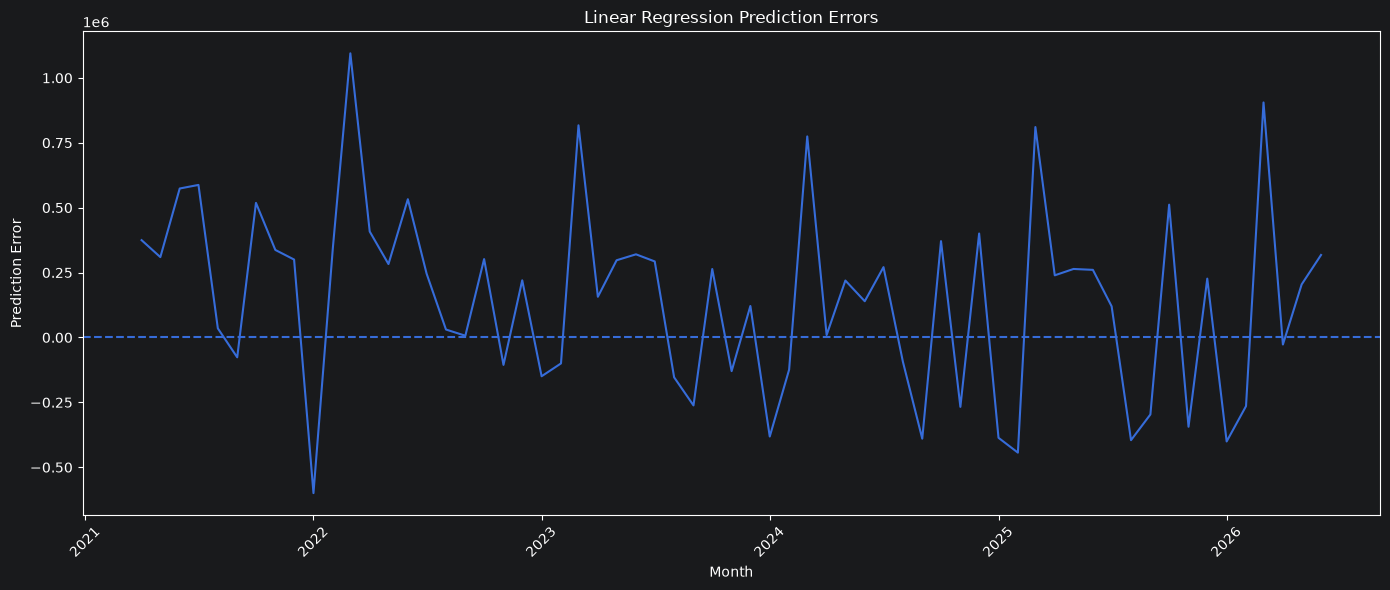

In [17]:
plt.figure(figsize=(14, 6))

plt.plot(
    evaluation["Month"],
    evaluation["Linear Error"]
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Month")
plt.ylabel("Prediction Error")
plt.title("Linear Regression Prediction Errors")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

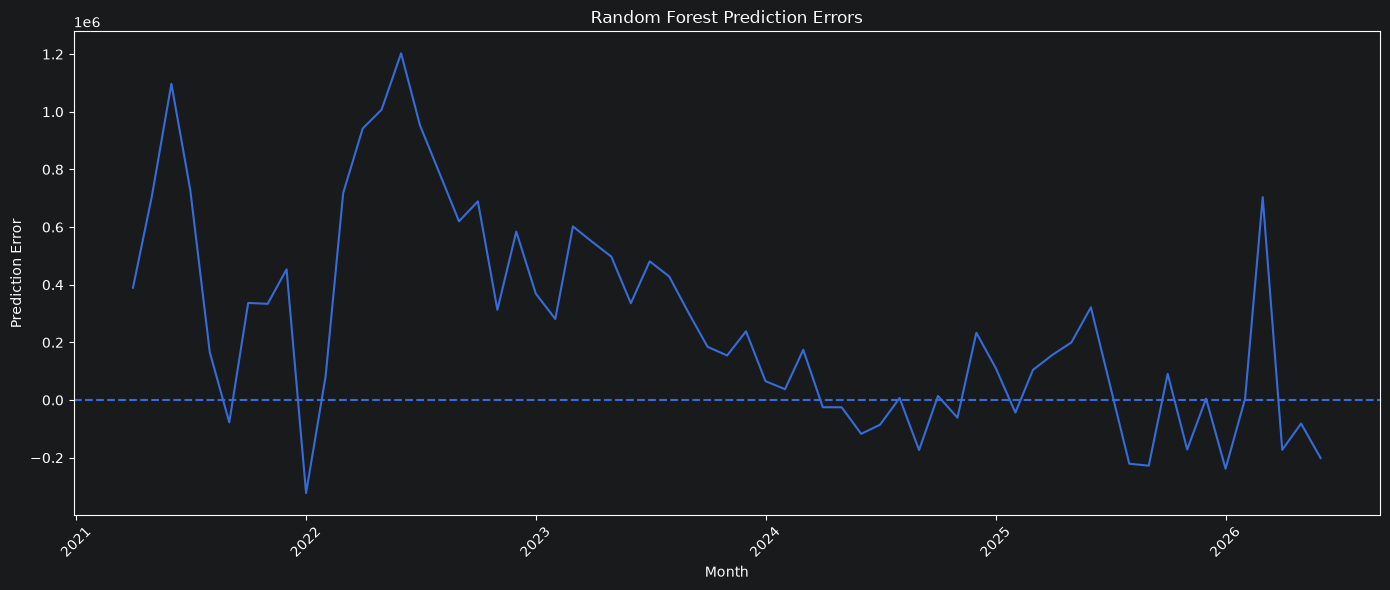

In [18]:
plt.figure(figsize=(14, 6))

plt.plot(
    evaluation["Month"],
    evaluation["Random Forest Error"]
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Month")
plt.ylabel("Prediction Error")
plt.title("Random Forest Prediction Errors")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

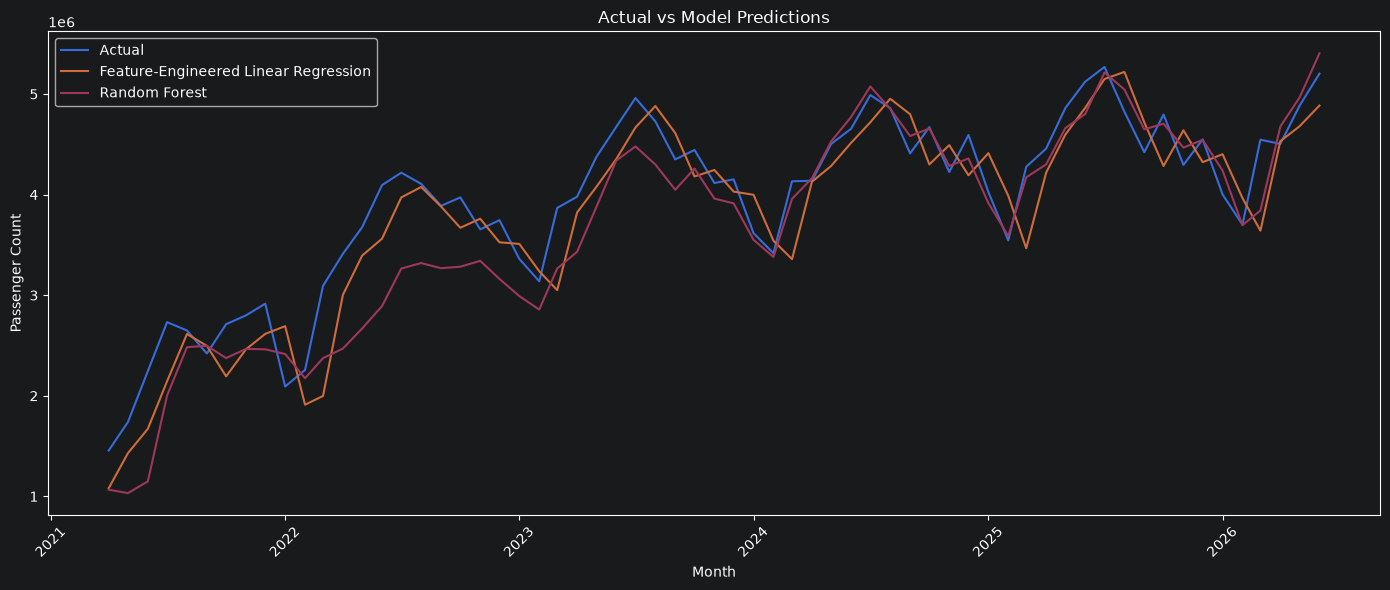

In [19]:
plt.figure(figsize=(14, 6))

plt.plot(
    evaluation["Month"],
    evaluation["Actual"],
    label="Actual"
)

plt.plot(
    evaluation["Month"],
    evaluation["Linear Regression"],
    label="Feature-Engineered Linear Regression"
)

plt.plot(
    evaluation["Month"],
    evaluation["Random Forest"],
    label="Random Forest"
)

plt.xlabel("Month")
plt.ylabel("Passenger Count")
plt.title("Actual vs Model Predictions")

plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [20]:
evaluation[
    [
        "Month",
        "Actual",
        "Linear Regression",
        "Linear Absolute Error"
    ]
].sort_values(
    "Linear Absolute Error",
    ascending=False
).head(10)

,Month,Actual,Linear Regression,Linear Absolute Error
11,2022-03-01,3092467,1.997888e+06,1.094579e+06
59,2026-03-01,4546149,3.640820e+06,9.053289e+05
23,2023-03-01,3867517,3.050251e+06,8.172656e+05
47,2025-03-01,4276931,3.466390e+06,8.105411e+05
35,2024-03-01,4132743,3.358259e+06,7.744839e+05
9,2022-01-01,2092568,2.692188e+06,5.996196e+05
3,2021-07-01,2732010,2.144374e+06,5.876356e+05
2,2021-06-01,2245539,1.671740e+06,5.737989e+05
14,2022-06-01,4094678,3.562095e+06,5.325832e+05
6,2021-10-01,2711638,2.193141e+06,5.184975e+05


In [21]:
evaluation["Calendar Month"] = (
    evaluation["Month"].dt.month
)

In [22]:
monthly_error = (
    evaluation
    .groupby("Calendar Month")["Linear Absolute Error"]
    .mean()
)

print(monthly_error)

Calendar Month
1     383572.500505
2     255360.595262
3     880439.716930
4     202592.675680
5     262890.029212
6     357415.660922
7     303429.633232
8     141549.135224
9     206321.028447
10    393341.659323
11    236763.523165
12    253745.599418
Name: Linear Absolute Error, dtype: float64


In [23]:
results = pd.DataFrame({
    "Model": [
        "Previous Month Baseline",
        "Linear Regression",
        "Feature-Engineered Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        326970.923077,
        322999.101710,
        320793.764324,
        334348.839762
    ],
    "RMSE": [
        384439.041719,
        377807.990227,
        388692.518306,
        447614.832360
    ]
})

results.round(2)

,Model,MAE,RMSE
0,Previous Month Baseline,326970.92,384439.04
1,Linear Regression,322999.10,377807.99
2,Feature-Engineered Linear Regression,320793.76,388692.52
3,Random Forest,334348.84,447614.83


In [24]:
baseline_mae = 326970.923077
baseline_rmse = 384439.041719

results["MAE Change vs Baseline (%)"] = (
    (results["MAE"] - baseline_mae)
    / baseline_mae
    * 100
)

results["RMSE Change vs Baseline (%)"] = (
    (results["RMSE"] - baseline_rmse)
    / baseline_rmse
    * 100
)

results.round(2)

,Model,MAE,RMSE,MAE Change vs Baseline (%),RMSE Change vs Baseline (%)
0,Previous Month Baseline,326970.92,384439.04,0.00,0.00
1,Linear Regression,322999.10,377807.99,-1.21,-1.72
2,Feature-Engineered Linear Regression,320793.76,388692.52,-1.89,1.11
3,Random Forest,334348.84,447614.83,2.26,16.43


In [25]:
print(results.round(2))

                                  Model        MAE       RMSE  \
0               Previous Month Baseline  326970.92  384439.04   
1                     Linear Regression  322999.10  377807.99   
2  Feature-Engineered Linear Regression  320793.76  388692.52   
3                         Random Forest  334348.84  447614.83   

   MAE Change vs Baseline (%)  RMSE Change vs Baseline (%)  
0                        0.00                         0.00  
1                       -1.21                        -1.72  
2                       -1.89                         1.11  
3                        2.26                        16.43  


Day 7 Observations

 **Overall Model Comparison**

The models gave varying results for the various evaluation metrics. The best model in terms of MAE was Feature-Engineered Linear Regression with an error of 320,793.76, and the best model in terms of RMSE was the basic Linear Regression model which had an error of 377,807.99.

The month-over-month change from the baseline was relatively small. The maximum improvement for the MAE and RMSE were 1.89% and 1.72%, respectively. The Random Forest was the poorest performer on both metrics when compared to their baselines.

This illustrates that performance did not necessarily improve with the addition of features, or with using a more complicated model.

 **The errors of linear regression.**

The errors of the Linear Regression model seem to be somewhat randomly distributed around zero over the test period, and there is no clear evidence of either continual overprediction or underprediction.

There are some larger errors during the post-COVID recovery period, such as large errors around the end of 2021 and the beginning of 2022. These errors have a greater influence on RMSE than do smaller errors.

 The error pattern would be random in the case of random forest.

The Random Forest error chart has a well-defined directionality during most of 2021-2023. Errors were mainly positive, as the model often underestimated passenger demand during this period (some individual errors were more than 1 million passengers).

The errors start to get smaller and more mixed towards the end of the test period. This implies that some of the noisy fluctuation in the number of passengers within the recovery period was not well captured by the Random Forest.

Target range for training and test were also compared. The training target ranged from 138,817 to 5,742,437 passengers, while the test target ranged from 1,455,944 to 5,269,263. Thus, test data fell within the range of the target data for the training. This is not because the Random Forest's predictions are outside the range of the training target, as they were.

 **Monthly Error Analysis**

At an average of around 880,440 passengers, the highest absolute error for Linear Regression was in March. Significantly more than the next highest months (October and January).

Five out of the ten biggest individual Linear Regression errors were in March also:

- March 2022: 1,094,579
- March 2026: 905,329
- March 2023: 817,266
- March 2025: 810,541
- March 2024: 774,484

This indicates that the feature set in use may be especially hard to predict in March.

This could be attributed to the variation in demand from February to March. The model is very data dependent on historic passenger numbers; it is possible that a large increase or decrease in the previous month will not be sufficient to predict a large increase in the following month.

 **Key Conclusion**

The results demonstrate that none of the models tested outperforms the baseline (naive) model of the previous month significantly. The basic Linear Regression showed the lowest RMSE while Feature-Engineered Linear Regression showed the lowest MAE. Random Forest was less good than the baseline on both measures.

The error analysis also reveals that the models have a poor performance when the demands change rapidly, such as in the post-COVID recovery period for some observations in March.

Overall, the results indicate that there is a need to have more "informative" explanatory variables rather than increase the complexity of the models to improve this forecasting problem.

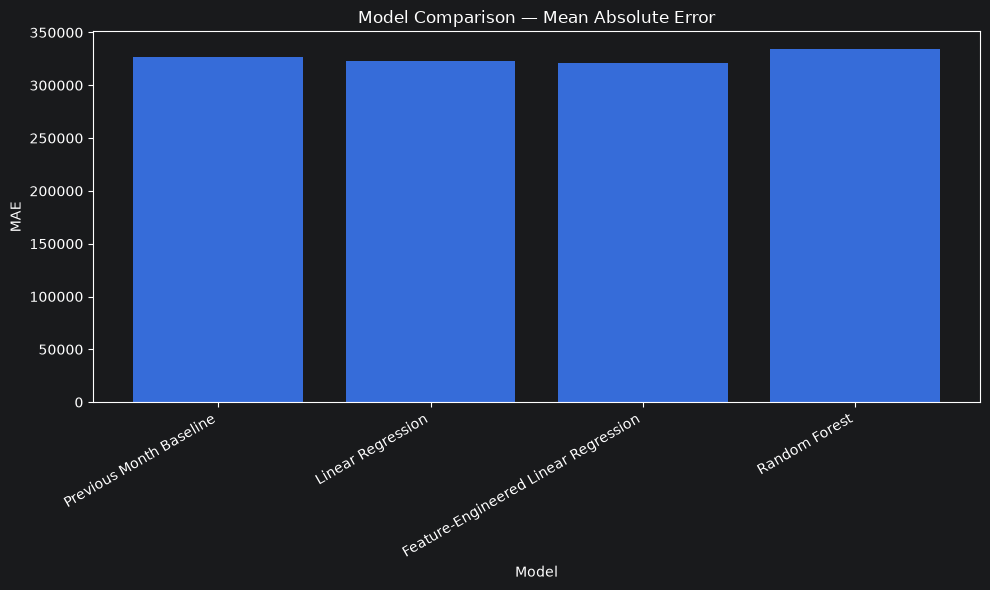

In [27]:
plt.figure(figsize=(10, 6))

plt.bar(
    results["Model"],
    results["MAE"]
)

plt.xlabel("Model")
plt.ylabel("MAE")
plt.title("Model Comparison \u2014 Mean Absolute Error")

plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

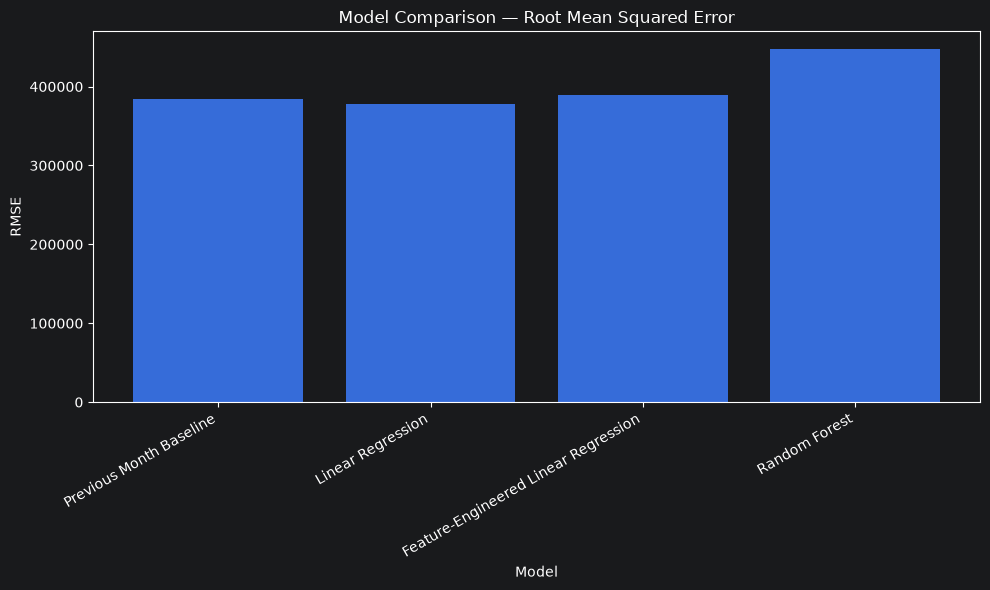

In [26]:
plt.figure(figsize=(10, 6))

plt.bar(
    results["Model"],
    results["RMSE"]
)

plt.xlabel("Model")
plt.ylabel("RMSE")
plt.title("Model Comparison \u2014 Root Mean Squared Error")

plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

# Final Conclusion

This project compared a previous-month baseline, Linear Regression, feature-engineered Linear Regression, and Random Forest for monthly passenger demand forecasting.

The feature-engineered Linear Regression achieved the lowest MAE of 320,793.76, while the basic Linear Regression achieved the lowest RMSE of 377,807.99 among the tested models.

The Random Forest produced higher MAE and RMSE on the test period.

The results demonstrate that additional model complexity does not necessarily improve forecasting performance. The analysis also showed that the largest prediction errors did not follow a clear and consistent pattern.

Further improvements would require additional explanatory variables, stronger time-series validation, and potentially other forecasting approaches.